# 데이터 분석 및 전처리

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

## 수집 데이터 종합 : "original_data.csv"

In [16]:
ORIGINAL_FILE_NAME = "original_data.csv"

if not os.path.exists(ORIGINAL_FILE_NAME) :
    try :
        df1 = pd.read_csv("steam_user_games_1.csv")
        df2 = pd.read_csv("steam_user_games_2.csv")
        df3 = pd.read_csv("steam_user_games_3.csv")
        df4 = pd.read_csv("steam_user_games_4_5_6.csv")

        merged = pd.concat([df1, df2, df3, df4], ignore_index=True)
        merged.to_csv("original_data.csv", index=False)
        
        print(ORIGINAL_FILE_NAME, "파일 생성 완료")
        
    except Exception as e :
        print(ORIGINAL_FILE_NAME, "파일 생성 실패")
else :
    print(ORIGINAL_FILE_NAME, "파일 확인 완료")

original_df = pd.read_csv(ORIGINAL_FILE_NAME)

original_data.csv 파일 확인 완료


## 0. 원본 데이터 orignal_df 형태

In [31]:
print("데이터 shape:", original_df.shape)
original_df.head(2)

데이터 shape: (27000, 16)


,steamid,appid,game_name,playtime_hours,recent_playtime_hours,genre,tags,steam_categories,total_reviews,positive_reviews,negative_reviews,rating_by_reviews,recommendations,metacritic,release_date,price(원)
0,76561199478662488,105600,Terraria,359.42,0.35,"Action, Adventure, Indie, RPG","Open World Survival Craft, Sandbox, Survival, ...","Single-player, Multi-player, PvP, Online PvP, ...",1546282,1505737,40545,97.38,1232905,83,"16 May, 2011",11000.0
1,76561199478662488,1281930,tModLoader,357.25,0.35,"Action, Adventure, Indie, RPG, Free To Play","Adventure, Free to Play, Action, Indie, RPG, M...","Single-player, Multi-player, PvP, Online PvP, ...",379134,368235,10899,97.13,0,Unknown,"16 May, 2020",0.0


## 1. 결측치 파악
- placeholder는 "Unknown" 등 null 이외 결측치에 들어갈 값 후보
- metaciritc 점수는 결측치 비율 매우 높음

In [24]:
# "Unknown" 검사
# NULL(NaN) + "Unknown" 등 placeholder 결측치 함께 체크
placeholder_values = ['Unknown', 'unknown', 'UNKNOWN', 'N/A', 'None', '', '-']

na_count = original_df.isnull().sum()
placeholder_count = original_df.apply(lambda col: col.isin(placeholder_values).sum())

missing_summary = pd.DataFrame({
    'null 개수': na_count,
    'placeholder 개수': placeholder_count,
    'total_missing': na_count + placeholder_count,
})
missing_summary['결측치 비율(%)'] = (missing_summary['total_missing'] / len(original_df) * 100).round(2)
missing_summary.sort_values('total_missing', ascending=False)

,null 개수,placeholder 개수,total_missing,결측치 비율(%)
metacritic,0,13800,13800,51.11
tags,0,3804,3804,14.09
price(원),0,3379,3379,12.51
steam_categories,0,2208,2208,8.18
genre,0,2199,2199,8.14
release_date,74,2117,2191,8.11
rating_by_reviews,0,35,35,0.13
steamid,0,0,0,0.00
appid,0,0,0,0.00
game_name,0,0,0,0.00


## 2. 중복 행 개수 파악
- 중복된 데이터 660개로 매우 많음

In [26]:
dup_count = original_df.duplicated(subset=['steamid', 'appid']).sum()
print(f"(steamid, appid) 중복 행 수: {dup_count}")
# 중복 행 전체 보기
# original_df[original_df.duplicated(subset=['steamid', 'appid'], keep=False)].sort_values(['steamid', 'appid'])

(steamid, appid) 중복 행 수: 660


## 3. 데이터 크기
- 중복 없는 유저 수 : 878
- 중복 없는 게임 수 : 3564

In [32]:
n_users = original_df['steamid'].nunique()
n_games = original_df['appid'].nunique()
n_rows = len(original_df)
sparsity = n_rows / (n_users * n_games)

print(f"중복 없는 유저 수: {n_users:,}")
print(f"중복 없는 게임 수: {n_games:,}")
print(f"전체 행(보유 기록) 수: {n_rows:,}")
print(f"밀도(density): {sparsity:.6f}  (가능한 유저-게임 조합 중 데이터가 존재하는 조합의 비율)")

중복 없는 유저 수: 878
중복 없는 게임 수: 3,564
전체 행(보유 기록) 수: 27,000
밀도(density): 0.008628  (가능한 유저-게임 조합 중 데이터가 존재하는 조합의 비율)


## 4. 게임별 보유 유저 표본 수 분포

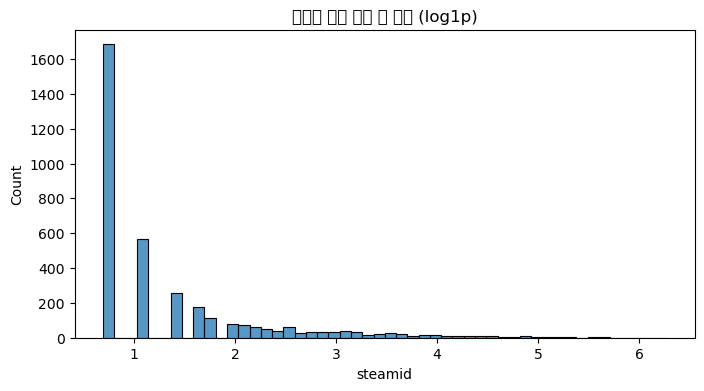

상위 10개 게임이 전체 보유 기록에서 차지하는 비중:
10.33%


,game_name,owner_count
appid,,
730,Counter-Strike 2,529
105600,Terraria,304
271590,Grand Theft Auto V Legacy,298
550,Left 4 Dead 2,280
4000,Garry's Mod,263
431960,Wallpaper Engine,248
1091500,Cyberpunk 2077,204
242760,The Forest,203
578080,PUBG: BATTLEGROUNDS,201


In [39]:
users_per_game = original_df.groupby('appid')['steamid'].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(np.log1p(users_per_game), bins=50, ax=ax)
ax.set_title('게임별 소유 유저 수 분포 (log1p)')
plt.show()

print("상위 10개 게임이 전체 보유 기록에서 차지하는 비중:")
top10_share = users_per_game.head(10).sum() / users_per_game.sum() * 100
print(f"{top10_share:.2f}%")
users_per_game.head(10)

appid_to_name = original_df.drop_duplicates(subset='appid').set_index('appid')['game_name']

top10_df = users_per_game.head(10).rename('owner_count').to_frame()
top10_df.insert(0, 'game_name', top10_df.index.map(appid_to_name))
top10_df